# GPR + Bayesian optimisation: next-best REE targets

**Objective:** rank unsampled grid cells in northern Curnamona for the next REE exploration step.

This notebook fits a **Gaussian process regressor** on binary labels:

- `y = 1` known REE occurrence
- `y = 0` sampled background (not proven barren)

The GP predicts a continuous prospectivity score `mu` and uncertainty `sigma`.  
Next-best locations use UCB: `acquisition = mu + kappa * sigma`.

Geochemistry enters as the existing ILR+RPCA components `V1`–`V7` (not raw La/Y, and not the prediction target).

Run cells **from top to bottom**.

In [1]:
import importlib.util
import subprocess
import sys

print("Python:", sys.executable, flush=True)
print("If this is not Geology_Project, switch kernel: Geology_Project, then re-run.", flush=True)

# Do not pip-install geopandas here — that can sit silent for many minutes.
needed = [
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("scikit-learn", "sklearn"),
]
missing = [pkg for pkg, mod in needed if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing (this may take a minute):", ", ".join(missing), flush=True)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--disable-pip-version-check", *missing]
    )
    print("Install finished.", flush=True)
else:
    print("Required packages are already installed.", flush=True)

if importlib.util.find_spec("geopandas") is None:
    print("geopandas not found — maps will skip the shapefile overlay.", flush=True)
else:
    print("geopandas is available.", flush=True)

Python: c:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Geology\Geology_Project\Scripts\python.exe
If this is not Geology_Project, switch kernel: Geology_Project, then re-run.
Required packages are already installed.
geopandas is available.


In [2]:
%matplotlib inline

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

try:
    import geopandas as gpd
except ImportError:
    gpd = None

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120


def show_figure(fig):
    display(fig)
    plt.close(fig)


def find_project_dirs():
    here = Path.cwd().resolve()
    candidates = [
        here / "Files needed for runing",
        here / "MPM_Curnamona_REE" / "Files needed for runing",
        here.parent / "MPM_Curnamona_REE" / "Files needed for runing",
    ]
    for path in candidates:
        if (path / "Output_Features_Generated").exists():
            return path
    raise FileNotFoundError("Could not find Files needed for runing. Open the notebook from Geology or MPM_Curnamona_REE.")


RUN_DIR = find_project_dirs()
FEAT_DIR = RUN_DIR / "Output_Features_Generated"
INPUT_DIR = RUN_DIR / "Input_Data_Layers"
OUT_DIR = RUN_DIR.parent / "gpr_bayesopt_outputs"
OUT_DIR.mkdir(exist_ok=True)
print("Features:", FEAT_DIR)
print("Outputs:", OUT_DIR)

Features: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Geology\MPM_Curnamona_REE\Files needed for runing\Output_Features_Generated
Outputs: C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Geology\MPM_Curnamona_REE\gpr_bayesopt_outputs


## Load training table and prediction grid

- **Train:** `combined_dataset_109.csv` — `X`, `Y`, evidence features, `label`
- **Predict:** regular-grid features + coordinates from the ILR-RPCA regular file

Only 7 known REE sites exist. Background (`label = 0`) is downsampled so the regressor is not swamped by zeros.

In [3]:
train = pd.read_csv(FEAT_DIR / "combined_dataset_109.csv")
pred_feat = pd.read_csv(
    FEAT_DIR / "ALL_phyd0.0011t0.65_cheilrrpcabackd0.01_geo3_preddata_regular_109.csv"
)
pred_xy = pd.read_csv(FEAT_DIR / "ilrrpca_back_regular_pred_0p015_711_all_PC.csv")[["X", "Y"]]

if len(pred_feat) != len(pred_xy):
    raise ValueError(f"Grid size mismatch: features={len(pred_feat)}, coords={len(pred_xy)}")

rename = {
    **{f"Geochemical_PC{i}": f"V{i}" for i in range(1, 8)},
    "Archean_Early_Mesoproterozoic_Faults": "fault_distance",
    "Felsic_granite": "granite_distance",
    "Mesoproterozoic_strata": "strata_distance",
}
pred = pd.concat([pred_xy.reset_index(drop=True), pred_feat.rename(columns=rename)], axis=1)

feature_cols = [c for c in train.columns if c not in {"X", "Y", "label"}]
missing = [c for c in feature_cols if c not in pred.columns]
if missing:
    raise KeyError(f"Prediction table missing columns: {missing}")

print("Training rows:", len(train), " | label counts:\n", train["label"].value_counts().to_string())
print("Prediction cells:", len(pred))
print("Evidence features (n={}):".format(len(feature_cols)))
print("  Geochemistry V1-V7:", [c for c in feature_cols if c.startswith("V")])
print("  Geology:", [c for c in feature_cols if "distance" in c])
print("  Other:", len([c for c in feature_cols if not c.startswith("V") and "distance" not in c]), "geophysics/RS/DEM columns")
display(train[feature_cols + ["label"]].head(3))

Training rows: 392  | label counts:
 label
0.0    385
1.0      7
Prediction cells: 679
Evidence features (n=58):
  Geochemistry V1-V7: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7']
  Geology: ['fault_distance', 'granite_distance', 'strata_distance']
  Other: 48 geophysics/RS/DEM columns


,V1,V2,V3,V4,V5,V6,V7,fault_distance,granite_distance,strata_distance,...,Ferrous_Iron_Index_dissimilarity,Green_Vegetation_correlation,Gypsum_Index_mean,Kaolin_Group_Index_mean,Opaque_Index_correlation,Quartz_Index_dissimilarity,Silica_Index_dissimilarity,DEM_9s_dx,DEM_9s_dy,label
0,0.609500,0.917118,0.197669,0.784506,0.732592,0.405690,0.546006,0.794625,1.0,1.000000,...,0.263577,0.530530,0.009540,0.000286,0.953042,0.296498,0.151238,0.484437,0.566718,1.0
1,0.666318,0.451409,0.441213,0.330420,0.581882,0.348813,0.344876,0.982099,1.0,1.000000,...,0.427504,0.363012,0.003816,0.000000,0.477705,0.262847,0.342881,0.455937,0.523761,1.0
2,0.399347,0.469572,0.374074,0.496790,0.678884,0.460375,0.419096,0.816295,1.0,0.909544,...,0.400909,0.362845,0.034140,0.008087,0.384379,0.439745,0.371939,0.450044,0.537935,1.0


In [4]:
if gpd is not None:
    frame = gpd.read_file(INPUT_DIR / "GIS" / "Clip_frame.shp")
    min_occ = gpd.read_file(INPUT_DIR / "GIS" / "ree.shp")
    if frame.crs is None:
        frame = frame.set_crs("EPSG:4283")
    if min_occ.crs is None:
        min_occ = min_occ.set_crs(frame.crs)
    elif min_occ.crs != frame.crs:
        min_occ = min_occ.to_crs(frame.crs)
    bounds = frame.total_bounds
    extent = [bounds[0], bounds[2], bounds[1], bounds[3]]
    print("REE shapefile points:", len(min_occ))
else:
    frame = None
    min_occ = None
    extent = [train["X"].min(), train["X"].max(), train["Y"].min(), train["Y"].max()]
    print("geopandas unavailable — using training coordinates for map extent.")

known_xy = train.loc[train["label"] == 1, ["X", "Y"]].to_numpy()
print("Known REE training points:", len(known_xy))

REE shapefile points: 7
Known REE training points: 7


## Balance training labels and fit GPR

`y` is a **numeric prospectivity target** (1 vs 0), not a class probability from a classifier.  
Keep every positive and 10 background cells per positive (random seed 42).

In [5]:
RANDOM_STATE = 42
NEG_PER_POS = 10
N_PCA = 15
KAPPA = 1.5
BUFFER_DEG = 0.02  # ~2 km; cells closer than this to a known REE are not ranked
TOP_N = 20

pos = train[train["label"] == 1]
neg = train[train["label"] == 0]
n_neg = min(len(neg), len(pos) * NEG_PER_POS)
train_fit = pd.concat(
    [pos, neg.sample(n=n_neg, random_state=RANDOM_STATE)],
    ignore_index=True,
)
print(f"Fit on {len(train_fit)} rows ({len(pos)} positives, {n_neg} background)")

X_fit = train_fit[feature_cols].to_numpy(dtype=float)
y_fit = train_fit["label"].to_numpy(dtype=float)
X_pred = pred[feature_cols].to_numpy(dtype=float)

scaler = StandardScaler()
X_fit_s = scaler.fit_transform(X_fit)
X_pred_s = scaler.transform(X_pred)

n_comp = min(N_PCA, X_fit_s.shape[0] - 1, X_fit_s.shape[1])
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
Z_fit = pca.fit_transform(X_fit_s)
Z_pred = pca.transform(X_pred_s)
print(f"PCA components: {n_comp} | variance explained: {pca.explained_variance_ratio_.sum():.3f}")

kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * Matern(length_scale=1.0, nu=1.5, length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1.0))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=1,
    random_state=RANDOM_STATE,
)
gpr.fit(Z_fit, y_fit)
print("Learned kernel:", gpr.kernel_)

mu, sigma = gpr.predict(Z_pred, return_std=True)
pred = pred.copy()
pred["mu"] = mu
pred["sigma"] = sigma
pred["acquisition"] = mu + KAPPA * sigma
print(pd.DataFrame({"mu": mu, "sigma": sigma, "acquisition": pred["acquisition"]}).describe().round(3))

Fit on 77 rows (7 positives, 70 background)
PCA components: 15 | variance explained: 0.764
Learned kernel: 1.06**2 * Matern(length_scale=3.62, nu=1.5) + WhiteKernel(noise_level=1e-05)
            mu    sigma  acquisition
count  679.000  679.000      679.000
mean     0.105    0.250        0.480
std      0.146    0.025        0.148
min     -0.102    0.169        0.224
25%      0.013    0.233        0.382
50%      0.063    0.250        0.455
75%      0.147    0.266        0.537
max      0.929    0.304        1.213


## Rank next-best cells

Cells within `BUFFER_DEG` of a known REE are masked so the list is **new ground**.

In [6]:
def min_dist_deg(points, known):
    d = np.sqrt(((points[:, None, :] - known[None, :, :]) ** 2).sum(axis=2))
    return d.min(axis=1)


pred["dist_known_ree_deg"] = min_dist_deg(pred[["X", "Y"]].to_numpy(), known_xy)
eligible = pred[pred["dist_known_ree_deg"] >= BUFFER_DEG].copy()
ranked = eligible.sort_values("acquisition", ascending=False).reset_index(drop=True)
ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))
top = ranked.head(TOP_N)[
    ["rank", "X", "Y", "mu", "sigma", "acquisition", "dist_known_ree_deg"]
]

out_csv = OUT_DIR / "next_best_ree_targets.csv"
full_csv = OUT_DIR / "grid_gpr_predictions.csv"
top.to_csv(out_csv, index=False)
pred[["X", "Y", "mu", "sigma", "acquisition", "dist_known_ree_deg"]].to_csv(full_csv, index=False)

print(f"Eligible cells (outside {BUFFER_DEG} deg buffer): {len(eligible)} / {len(pred)}")
print(f"Wrote {out_csv}")
display(top.round(4))

Eligible cells (outside 0.02 deg buffer): 586 / 679
Wrote C:\Users\liyuan.liu\OneDrive - CPI\Learning and Development\Geology\MPM_Curnamona_REE\gpr_bayesopt_outputs\next_best_ree_targets.csv


,rank,X,Y,mu,sigma,acquisition,dist_known_ree_deg
0,1,139.4556,-30.1574,0.5851,0.2706,0.9910,0.0227
1,2,139.3950,-30.2046,0.6378,0.2347,0.9898,0.0322
2,3,139.4455,-30.1574,0.5656,0.2492,0.9393,0.0275
3,4,139.4455,-30.1668,0.5394,0.2604,0.9301,0.0354
4,5,139.4858,-30.1291,0.5456,0.2408,0.9069,0.0245
5,6,139.4152,-30.1857,0.5244,0.2498,0.8991,0.0555
6,7,139.4354,-30.1291,0.5027,0.2436,0.8681,0.0277
7,8,139.3950,-30.2140,0.4978,0.2292,0.8416,0.0337
8,9,139.3950,-30.1857,0.4859,0.2371,0.8415,0.0370
9,10,139.4152,-30.1951,0.4025,0.2694,0.8066,0.0531


## Maps: prospectivity, uncertainty, next-best score

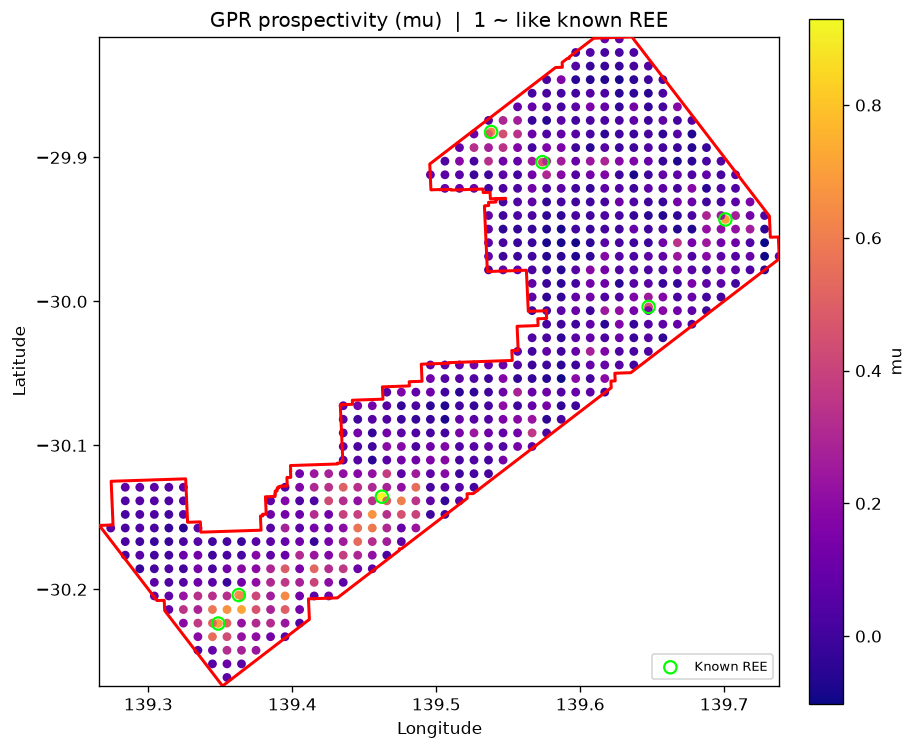

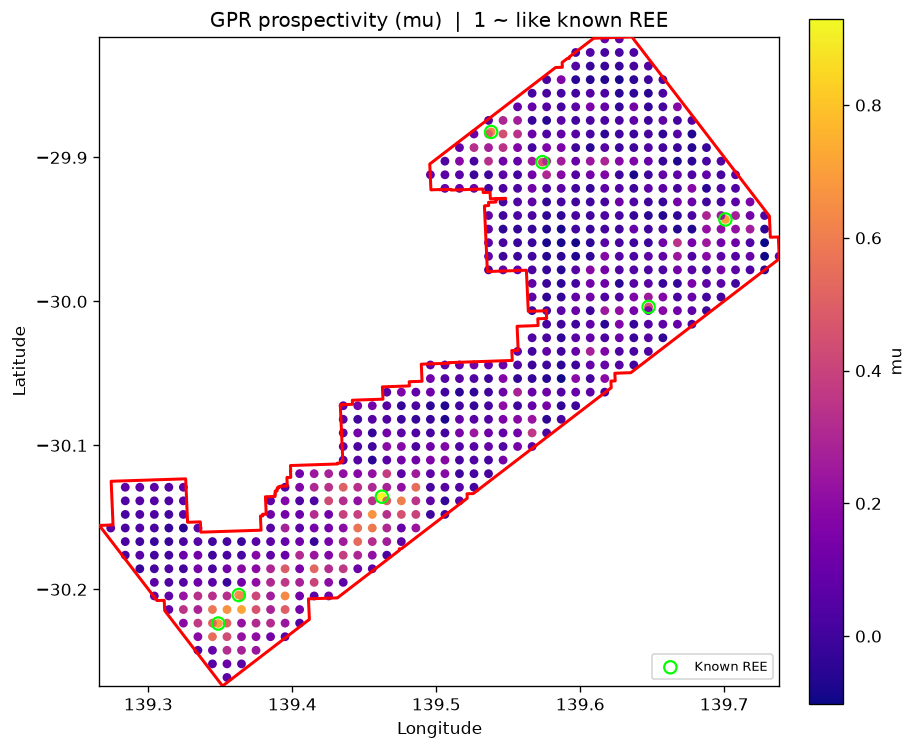

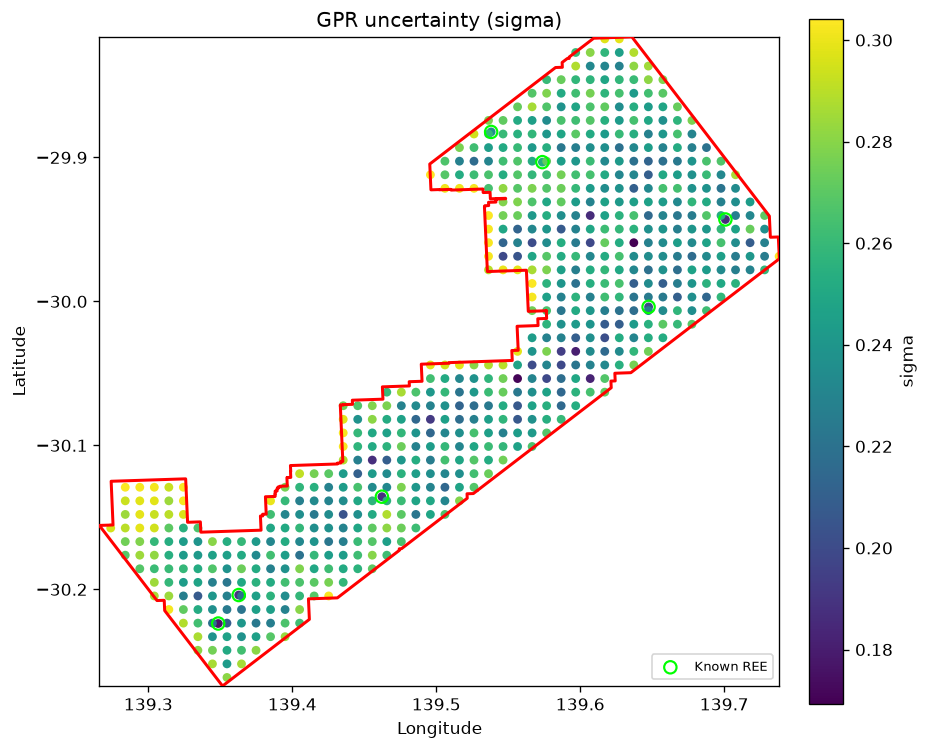

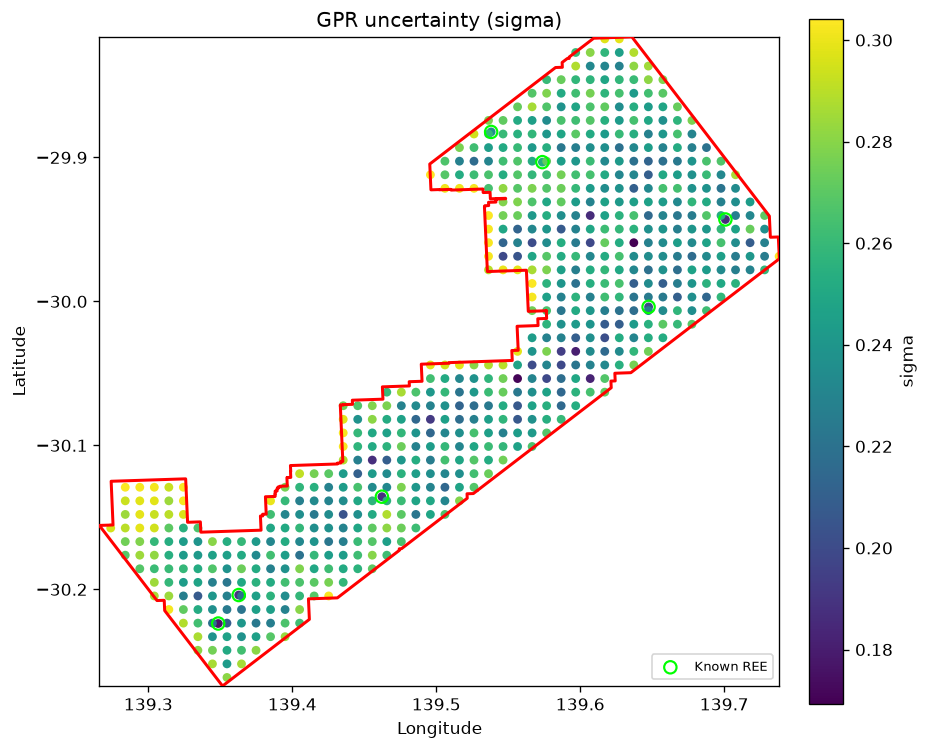

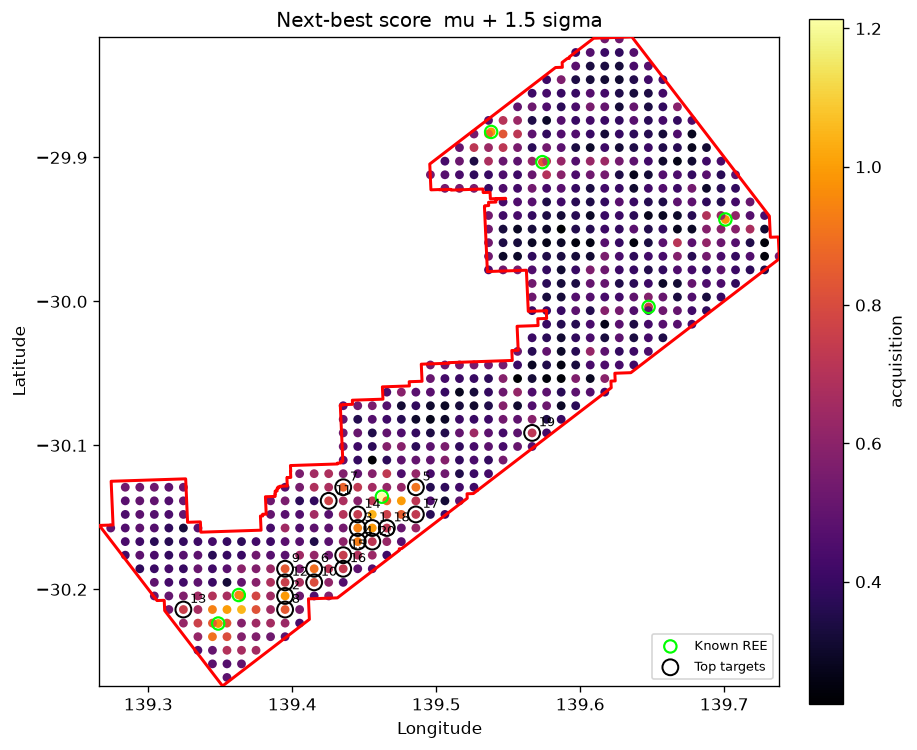

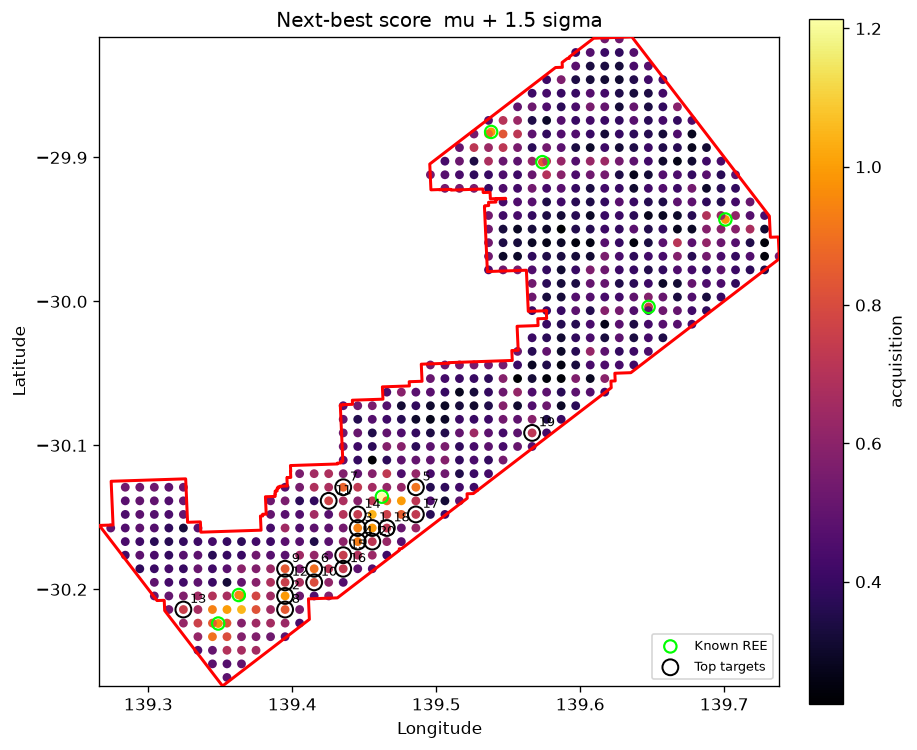

In [7]:
def plot_grid(df, column, title, cmap, points=None):
    fig, ax = plt.subplots(figsize=(8, 8))
    sc = ax.scatter(
        df["X"], df["Y"], c=df[column], cmap=cmap, s=28, edgecolors="none", zorder=2
    )
    if frame is not None:
        frame.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1.8, zorder=3)
    if min_occ is not None:
        min_occ.plot(
            ax=ax, color="none", edgecolor="lime", markersize=55, linewidth=1.3, zorder=4, label="Known REE"
        )
    else:
        ax.scatter(
            known_xy[:, 0], known_xy[:, 1],
            facecolors="none", edgecolors="lime", s=55, linewidths=1.3, zorder=4, label="Known REE",
        )
    if points is not None:
        ax.scatter(
            points["X"],
            points["Y"],
            facecolors="none",
            edgecolors="black",
            s=90,
            linewidths=1.2,
            zorder=5,
            label="Top targets",
        )
        for _, row in points.iterrows():
            ax.annotate(
                int(row["rank"]),
                (row["X"], row["Y"]),
                textcoords="offset points",
                xytext=(4, 4),
                fontsize=8,
                zorder=6,
            )
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(loc="lower right", fontsize=8)
    fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label=column)
    fig.savefig(OUT_DIR / f"{column}_map.png", bbox_inches="tight", dpi=150)
    show_figure(fig)


plot_grid(pred, "mu", "GPR prospectivity (mu)  |  1 ~ like known REE", "plasma")
plot_grid(pred, "sigma", "GPR uncertainty (sigma)", "viridis")
plot_grid(
    pred,
    "acquisition",
    f"Next-best score  mu + {KAPPA} sigma",
    "inferno",
    points=top,
)

`mu` is a **regression score** toward the 0/1 training labels, not a calibrated probability. Values can fall slightly outside 0–1.  
Increase `KAPPA` to explore uncertain ground; decrease it to focus on high `mu`.